In [551]:
import warnings
warnings.filterwarnings('ignore')

In [552]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [553]:
df_leads = pd.read_csv("../../ml_data/Leads.csv")

In [554]:
df_leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [555]:
df_leads.shape

(9240, 37)

In [556]:
# Check duplicate rows count
duplicat_rows = df_leads[df_leads.duplicated()]
duplicat_rows.shape

(0, 37)

In [557]:
# Print missing values and will drop incase this number is small
print(df_leads.isnull().sum())

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

In [558]:
# check records where data are more 30% null
null_percentage =df_leads.isnull().sum()/len(df_leads)*100
null_percentage

filter_col_greater_null_values = null_percentage[null_percentage > 30]
filter_col_greater_null_values

Tags                           36.287879
Lead Quality                   51.590909
Asymmetrique Activity Index    45.649351
Asymmetrique Profile Index     45.649351
Asymmetrique Activity Score    45.649351
Asymmetrique Profile Score     45.649351
dtype: float64

In [559]:
df_leads['Tags'].value_counts()

Tags
Will revert after reading the email                  2072
Ringing                                              1203
Interested in other courses                           513
Already a student                                     465
Closed by Horizzon                                    358
switched off                                          240
Busy                                                  186
Lost to EINS                                          175
Not doing further education                           145
Interested  in full time MBA                          117
Graduation in progress                                111
invalid number                                         83
Diploma holder (Not Eligible)                          63
wrong number given                                     47
opp hangup                                             33
number not provided                                    27
in touch with EINS                                     12
Lost to O

In [560]:
df_leads['Lead Quality'].value_counts()

Lead Quality
Might be             1560
Not Sure             1092
High in Relevance     637
Worst                 601
Low in Relevance      583
Name: count, dtype: int64

In [561]:
df_leads['Asymmetrique Activity Index'].value_counts()

Asymmetrique Activity Index
02.Medium    3839
01.High       821
03.Low        362
Name: count, dtype: int64

In [562]:
df_leads['Asymmetrique Profile Index'].value_counts()

Asymmetrique Profile Index
02.Medium    2788
01.High      2203
03.Low         31
Name: count, dtype: int64

In [563]:
df_leads['Asymmetrique Activity Score'].value_counts()

Asymmetrique Activity Score
14.0    1771
15.0    1293
13.0     775
16.0     467
17.0     349
12.0     196
11.0      95
10.0      57
9.0        9
18.0       5
8.0        4
7.0        1
Name: count, dtype: int64

In [564]:
df_leads['Asymmetrique Profile Score'].value_counts()

Asymmetrique Profile Score
15.0    1759
18.0    1071
16.0     599
17.0     579
20.0     308
19.0     245
14.0     226
13.0     204
12.0      22
11.0       9
Name: count, dtype: int64

In [565]:
list_ = list(filter_col_greater_null_values.index)
list_

['Tags',
 'Lead Quality',
 'Asymmetrique Activity Index',
 'Asymmetrique Profile Index',
 'Asymmetrique Activity Score',
 'Asymmetrique Profile Score']

In [566]:
df_leads.drop(labels=list_, inplace=True, axis=1)
df_leads.shape

(9240, 31)

In [567]:
df_leads.isnull().sum()/len(df_leads)*100

Prospect ID                                       0.000000
Lead Number                                       0.000000
Lead Origin                                       0.000000
Lead Source                                       0.389610
Do Not Email                                      0.000000
Do Not Call                                       0.000000
Converted                                         0.000000
TotalVisits                                       1.482684
Total Time Spent on Website                       0.000000
Page Views Per Visit                              1.482684
Last Activity                                     1.114719
Country                                          26.634199
Specialization                                   15.562771
How did you hear about X Education               23.885281
What is your current occupation                  29.112554
What matters most to you in choosing a course    29.318182
Search                                            0.0000

In [568]:
df_leads['What matters most to you in choosing a course'].value_counts()

What matters most to you in choosing a course
Better Career Prospects      6528
Flexibility & Convenience       2
Other                           1
Name: count, dtype: int64

In [569]:
# Again df_leads['What matters most to you in choosing a course'] it's sales team provided column and have around 30% null values so will drop this col as well
df_leads.drop(labels=['What matters most to you in choosing a course'], inplace=True, axis=1)

In [570]:
df_leads['Lead Profile'].value_counts()

Lead Profile
Select                         4146
Potential Lead                 1613
Other Leads                     487
Student of SomeSchool           241
Lateral Student                  24
Dual Specialization Student      20
Name: count, dtype: int64

In [571]:
df_leads.drop(labels=['Lead Profile'], inplace=True, axis=1)

In [572]:
df_leads.drop('How did you hear about X Education', axis = 1, inplace = True)
df_leads.shape

(9240, 28)

In [573]:
null_col = df_leads.isnull().sum()/len(df_leads)*100
null_col [ null_col.values > 0 ]

Lead Source                         0.389610
TotalVisits                         1.482684
Page Views Per Visit                1.482684
Last Activity                       1.114719
Country                            26.634199
Specialization                     15.562771
What is your current occupation    29.112554
City                               15.367965
dtype: float64

In [574]:
df_leads['Country'].value_counts()

Country
India                   6492
United States             69
United Arab Emirates      53
Singapore                 24
Saudi Arabia              21
United Kingdom            15
Australia                 13
Qatar                     10
Hong Kong                  7
Bahrain                    7
Oman                       6
France                     6
unknown                    5
South Africa               4
Nigeria                    4
Germany                    4
Kuwait                     4
Canada                     4
Sweden                     3
China                      2
Asia/Pacific Region        2
Uganda                     2
Bangladesh                 2
Italy                      2
Belgium                    2
Netherlands                2
Ghana                      2
Philippines                2
Russia                     1
Switzerland                1
Vietnam                    1
Denmark                    1
Tanzania                   1
Liberia                    1
Malays

In [575]:
def caluculate_null_value_percentage(df_leads):
    null_col = df_leads.isnull().sum()/len(df_leads)*100
    print(null_col [ null_col.values > 0 ])

In [576]:
# Will fill null values with India
df_leads['Country'] = df_leads['Country'].fillna('India')

caluculate_null_value_percentage(df_leads)

Lead Source                         0.389610
TotalVisits                         1.482684
Page Views Per Visit                1.482684
Last Activity                       1.114719
Specialization                     15.562771
What is your current occupation    29.112554
City                               15.367965
dtype: float64


In [577]:
df_leads['Country'].value_counts()

Country
India                   8953
United States             69
United Arab Emirates      53
Singapore                 24
Saudi Arabia              21
United Kingdom            15
Australia                 13
Qatar                     10
Hong Kong                  7
Bahrain                    7
Oman                       6
France                     6
unknown                    5
South Africa               4
Nigeria                    4
Germany                    4
Kuwait                     4
Canada                     4
Sweden                     3
China                      2
Asia/Pacific Region        2
Uganda                     2
Bangladesh                 2
Italy                      2
Belgium                    2
Netherlands                2
Ghana                      2
Philippines                2
Russia                     1
Switzerland                1
Vietnam                    1
Denmark                    1
Tanzania                   1
Liberia                    1
Malays

In [578]:
# Most of the request coming from India so will merge all other countries as Other 
df_leads.loc[df_leads['Country'] != 'India', 'Country'] = 'Other'
df_leads['Country'].value_counts()

Country
India    8953
Other     287
Name: count, dtype: int64

In [579]:
df_leads['City'].value_counts()

City
Mumbai                         3222
Select                         2249
Thane & Outskirts               752
Other Cities                    686
Other Cities of Maharashtra     457
Other Metro Cities              380
Tier II Cities                   74
Name: count, dtype: int64

In [580]:
df_leads.drop('City', axis = 1, inplace = True)

In [581]:
caluculate_null_value_percentage(df_leads)

Lead Source                         0.389610
TotalVisits                         1.482684
Page Views Per Visit                1.482684
Last Activity                       1.114719
Specialization                     15.562771
What is your current occupation    29.112554
dtype: float64


In [582]:
df_leads['Specialization'].value_counts()

Specialization
Select                               1942
Finance Management                    976
Human Resource Management             848
Marketing Management                  838
Operations Management                 503
Business Administration               403
IT Projects Management                366
Supply Chain Management               349
Banking, Investment And Insurance     338
Travel and Tourism                    203
Media and Advertising                 203
International Business                178
Healthcare Management                 159
Hospitality Management                114
E-COMMERCE                            112
Retail Management                     100
Rural and Agribusiness                 73
E-Business                             57
Services Excellence                    40
Name: count, dtype: int64

In [583]:
df_leads["Specialization"]=df_leads["Specialization"].fillna("np.nan")
df_leads.loc[df_leads['Specialization']=='Select','Specialization']='np.nan'
df_leads["Specialization"].value_counts()/len(df_leads['Specialization'].index)

Specialization
np.nan                               0.365801
Finance Management                   0.105628
Human Resource Management            0.091775
Marketing Management                 0.090693
Operations Management                0.054437
Business Administration              0.043615
IT Projects Management               0.039610
Supply Chain Management              0.037771
Banking, Investment And Insurance    0.036580
Travel and Tourism                   0.021970
Media and Advertising                0.021970
International Business               0.019264
Healthcare Management                0.017208
Hospitality Management               0.012338
E-COMMERCE                           0.012121
Retail Management                    0.010823
Rural and Agribusiness               0.007900
E-Business                           0.006169
Services Excellence                  0.004329
Name: count, dtype: float64

In [584]:
#dropping because around 36% data is null
df_leads.drop('Specialization', axis = 1, inplace = True)
df_leads.shape

(9240, 26)

In [585]:
caluculate_null_value_percentage(df_leads)

Lead Source                         0.389610
TotalVisits                         1.482684
Page Views Per Visit                1.482684
Last Activity                       1.114719
What is your current occupation    29.112554
dtype: float64


In [586]:
df_leads['What is your current occupation'].value_counts()

What is your current occupation
Unemployed              5600
Working Professional     706
Student                  210
Other                     16
Housewife                 10
Businessman                8
Name: count, dtype: int64

In [587]:
df_leads["What is your current occupation"]=df_leads["What is your current occupation"].fillna("np.nan")
df_leads['What is your current occupation'].value_counts()/len(df_leads['What is your current occupation'].index)*100

What is your current occupation
Unemployed              60.606061
np.nan                  29.112554
Working Professional     7.640693
Student                  2.272727
Other                    0.173160
Housewife                0.108225
Businessman              0.086580
Name: count, dtype: float64

In [588]:
# 60% of the people are unemployed those are potential leads so will impute null data to Unemployed
df_leads.loc[df_leads['What is your current occupation']=='np.nan','What is your current occupation']='Unemployed'

In [589]:
df_leads['What is your current occupation'].value_counts()/len(df_leads['What is your current occupation'].index)*100

What is your current occupation
Unemployed              89.718615
Working Professional     7.640693
Student                  2.272727
Other                    0.173160
Housewife                0.108225
Businessman              0.086580
Name: count, dtype: float64

In [590]:
caluculate_null_value_percentage(df_leads)

Lead Source             0.389610
TotalVisits             1.482684
Page Views Per Visit    1.482684
Last Activity           1.114719
dtype: float64


In [591]:
df_leads['Lead Source'].value_counts()

Lead Source
Google               2868
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
bing                    6
google                  5
Click2call              4
Press_Release           2
Social Media            2
Live Chat               2
youtubechannel          1
testone                 1
Pay per Click Ads       1
welearnblog_Home        1
WeLearn                 1
blog                    1
NC_EDM                  1
Name: count, dtype: int64

In [592]:
df_leads['Lead Source'] = df_leads['Lead Source'].fillna('np.nan')
df_leads['Lead Source'].value_counts()/len(df_leads['Lead Source'].index)*100

Lead Source
Google               31.038961
Direct Traffic       27.521645
Olark Chat           18.993506
Organic Search       12.489177
Reference             5.779221
Welingak Website      1.536797
Referral Sites        1.352814
Facebook              0.595238
np.nan                0.389610
bing                  0.064935
google                0.054113
Click2call            0.043290
Press_Release         0.021645
Social Media          0.021645
Live Chat             0.021645
youtubechannel        0.010823
testone               0.010823
Pay per Click Ads     0.010823
welearnblog_Home      0.010823
WeLearn               0.010823
blog                  0.010823
NC_EDM                0.010823
Name: count, dtype: float64

In [593]:
lead_items = df_leads['Lead Source'].value_counts()/len(df_leads['Lead Source'].index)*100
lead_items

Lead Source
Google               31.038961
Direct Traffic       27.521645
Olark Chat           18.993506
Organic Search       12.489177
Reference             5.779221
Welingak Website      1.536797
Referral Sites        1.352814
Facebook              0.595238
np.nan                0.389610
bing                  0.064935
google                0.054113
Click2call            0.043290
Press_Release         0.021645
Social Media          0.021645
Live Chat             0.021645
youtubechannel        0.010823
testone               0.010823
Pay per Click Ads     0.010823
welearnblog_Home      0.010823
WeLearn               0.010823
blog                  0.010823
NC_EDM                0.010823
Name: count, dtype: float64

In [594]:
l = lead_items[lead_items.values<10].index
list(l)

['Reference',
 'Welingak Website',
 'Referral Sites',
 'Facebook',
 'np.nan',
 'bing',
 'google',
 'Click2call',
 'Press_Release',
 'Social Media',
 'Live Chat',
 'youtubechannel',
 'testone',
 'Pay per Click Ads',
 'welearnblog_Home',
 'WeLearn',
 'blog',
 'NC_EDM']

In [595]:
for i in list(l):
    df_leads.loc[df_leads['Lead Source']==i,'Lead Source']='Other'

df_leads['Lead Source'].value_counts()/len(df_leads['Lead Source'].index)*100

Lead Source
Google            31.038961
Direct Traffic    27.521645
Olark Chat        18.993506
Organic Search    12.489177
Other              9.956710
Name: count, dtype: float64

In [596]:
caluculate_null_value_percentage(df_leads)

TotalVisits             1.482684
Page Views Per Visit    1.482684
Last Activity           1.114719
dtype: float64


In [597]:
df_leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 26 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Prospect ID                               9240 non-null   object 
 1   Lead Number                               9240 non-null   int64  
 2   Lead Origin                               9240 non-null   object 
 3   Lead Source                               9240 non-null   object 
 4   Do Not Email                              9240 non-null   object 
 5   Do Not Call                               9240 non-null   object 
 6   Converted                                 9240 non-null   int64  
 7   TotalVisits                               9103 non-null   float64
 8   Total Time Spent on Website               9240 non-null   int64  
 9   Page Views Per Visit                      9103 non-null   float64
 10  Last Activity                       

In [598]:
median_value = df_leads['Page Views Per Visit'].median()

df_leads.loc[df_leads['Page Views Per Visit'].isnull(), 'Page Views Per Visit'] = median_value

In [599]:
values=df_leads['TotalVisits'].median()

df_leads.loc[df_leads['TotalVisits'].isnull(),'TotalVisits']=values

In [600]:
caluculate_null_value_percentage(df_leads)

Last Activity    1.114719
dtype: float64


In [601]:
df_leads['Last Activity'] = df_leads['Last Activity'].fillna('np.nan')
df_leads['Last Activity'].value_counts()/len(df_leads['Last Activity'].index)*100

Last Activity
Email Opened                    37.196970
SMS Sent                        29.707792
Olark Chat Conversation         10.530303
Page Visited on Website          6.926407
Converted to Lead                4.632035
Email Bounced                    3.528139
Email Link Clicked               2.889610
Form Submitted on Website        1.255411
np.nan                           1.114719
Unreachable                      1.006494
Unsubscribed                     0.660173
Had a Phone Conversation         0.324675
Approached upfront               0.097403
View in browser link Clicked     0.064935
Email Received                   0.021645
Email Marked Spam                0.021645
Visited Booth in Tradeshow       0.010823
Resubscribed to emails           0.010823
Name: count, dtype: float64

In [602]:
lead_perc = df_leads['Last Activity'].value_counts()/len(df_leads['Last Activity'].index)*100
lead_perc

Last Activity
Email Opened                    37.196970
SMS Sent                        29.707792
Olark Chat Conversation         10.530303
Page Visited on Website          6.926407
Converted to Lead                4.632035
Email Bounced                    3.528139
Email Link Clicked               2.889610
Form Submitted on Website        1.255411
np.nan                           1.114719
Unreachable                      1.006494
Unsubscribed                     0.660173
Had a Phone Conversation         0.324675
Approached upfront               0.097403
View in browser link Clicked     0.064935
Email Received                   0.021645
Email Marked Spam                0.021645
Visited Booth in Tradeshow       0.010823
Resubscribed to emails           0.010823
Name: count, dtype: float64

In [603]:
df_leads.loc[df_leads['Last Activity'] == np.nan, 'Last Activity'] = 'Email Opened'

In [604]:
caluculate_null_value_percentage(df_leads)

Series([], dtype: float64)


In [605]:
df_leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 26 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Prospect ID                               9240 non-null   object 
 1   Lead Number                               9240 non-null   int64  
 2   Lead Origin                               9240 non-null   object 
 3   Lead Source                               9240 non-null   object 
 4   Do Not Email                              9240 non-null   object 
 5   Do Not Call                               9240 non-null   object 
 6   Converted                                 9240 non-null   int64  
 7   TotalVisits                               9240 non-null   float64
 8   Total Time Spent on Website               9240 non-null   int64  
 9   Page Views Per Visit                      9240 non-null   float64
 10  Last Activity                       

In [606]:
numerical_colmuns = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

In [607]:
categorical_columns = ['Lead Origin',
          'Lead Source',
          'Do Not Email',
          'Do Not Call',
          'Last Activity',
          'Country',
          'What is your current occupation',
          'Search',
          'Magazine',
          'Newspaper Article',
          'X Education Forums',
          'Newspaper',
          'Digital Advertisement',
          'Through Recommendations',
          'Receive More Updates About Our Courses',
          'Update me on Supply Chain Content',
          'Get updates on DM Content',
          'I agree to pay the amount through cheque',
          'A free copy of Mastering The Interview',
          'Last Notable Activity']
categorical_columns

['Lead Origin',
 'Lead Source',
 'Do Not Email',
 'Do Not Call',
 'Last Activity',
 'Country',
 'What is your current occupation',
 'Search',
 'Magazine',
 'Newspaper Article',
 'X Education Forums',
 'Newspaper',
 'Digital Advertisement',
 'Through Recommendations',
 'Receive More Updates About Our Courses',
 'Update me on Supply Chain Content',
 'Get updates on DM Content',
 'I agree to pay the amount through cheque',
 'A free copy of Mastering The Interview',
 'Last Notable Activity']

In [608]:
df_leads[categorical_columns].head()

,Lead Origin,Lead Source,Do Not Email,Do Not Call,Last Activity,Country,What is your current occupation,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Update me on Supply Chain Content,Get updates on DM Content,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,No,No,Page Visited on Website,India,Unemployed,No,No,No,No,No,No,No,No,No,No,No,No,Modified
1,API,Organic Search,No,No,Email Opened,India,Unemployed,No,No,No,No,No,No,No,No,No,No,No,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,No,Email Opened,India,Student,No,No,No,No,No,No,No,No,No,No,No,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,No,Unreachable,India,Unemployed,No,No,No,No,No,No,No,No,No,No,No,No,Modified
4,Landing Page Submission,Google,No,No,Converted to Lead,India,Unemployed,No,No,No,No,No,No,No,No,No,No,No,No,Modified


In [609]:
df_leads[ ].head()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit
0,0.0,0,0.0
1,5.0,674,2.5
2,2.0,1532,2.0
3,1.0,305,1.0
4,2.0,1428,1.0


In [610]:
df_leads.nunique()

Prospect ID                                 9240
Lead Number                                 9240
Lead Origin                                    5
Lead Source                                    5
Do Not Email                                   2
Do Not Call                                    2
Converted                                      2
TotalVisits                                   41
Total Time Spent on Website                 1731
Page Views Per Visit                         114
Last Activity                                 18
Country                                        2
What is your current occupation                6
Search                                         2
Magazine                                       1
Newspaper Article                              2
X Education Forums                             2
Newspaper                                      2
Digital Advertisement                          2
Through Recommendations                        2
Receive More Updates

In [611]:
df_leads['Magazine'].value_counts()

Magazine
No    9240
Name: count, dtype: int64

In [612]:
all_single_unique_element = df_leads.nunique()
z = all_single_unique_element[all_single_unique_element.values == 1]
single_var = list(z.index)
single_var

['Magazine',
 'Receive More Updates About Our Courses',
 'Update me on Supply Chain Content',
 'Get updates on DM Content',
 'I agree to pay the amount through cheque']

In [613]:
df_leads.drop(labels=single_var, inplace=True, axis=1)

In [614]:
categorical_columns = ['Lead Origin',
          'Lead Source',
          'Do Not Email',
          'Do Not Call',
          'Last Activity',
          'Country',
          'What is your current occupation',
          'Search',
          'Newspaper Article',
          'X Education Forums',
          'Newspaper',
          'Digital Advertisement',
          'Through Recommendations',
          'A free copy of Mastering The Interview',
          'Last Notable Activity']

In [615]:
non_binary_values = df_leads[categorical_columns].nunique()
z = non_binary_values[non_binary_values.values > 2]
non_binary_var = list(z.index)
non_binary_var

['Lead Origin',
 'Lead Source',
 'Last Activity',
 'What is your current occupation',
 'Last Notable Activity']

In [616]:
conversion_rate = (sum(df_leads['Converted']) / len(df_leads['Converted'].index)) * 100
conversion_rate

38.53896103896104

<Axes: xlabel='A free copy of Mastering The Interview', ylabel='count'>

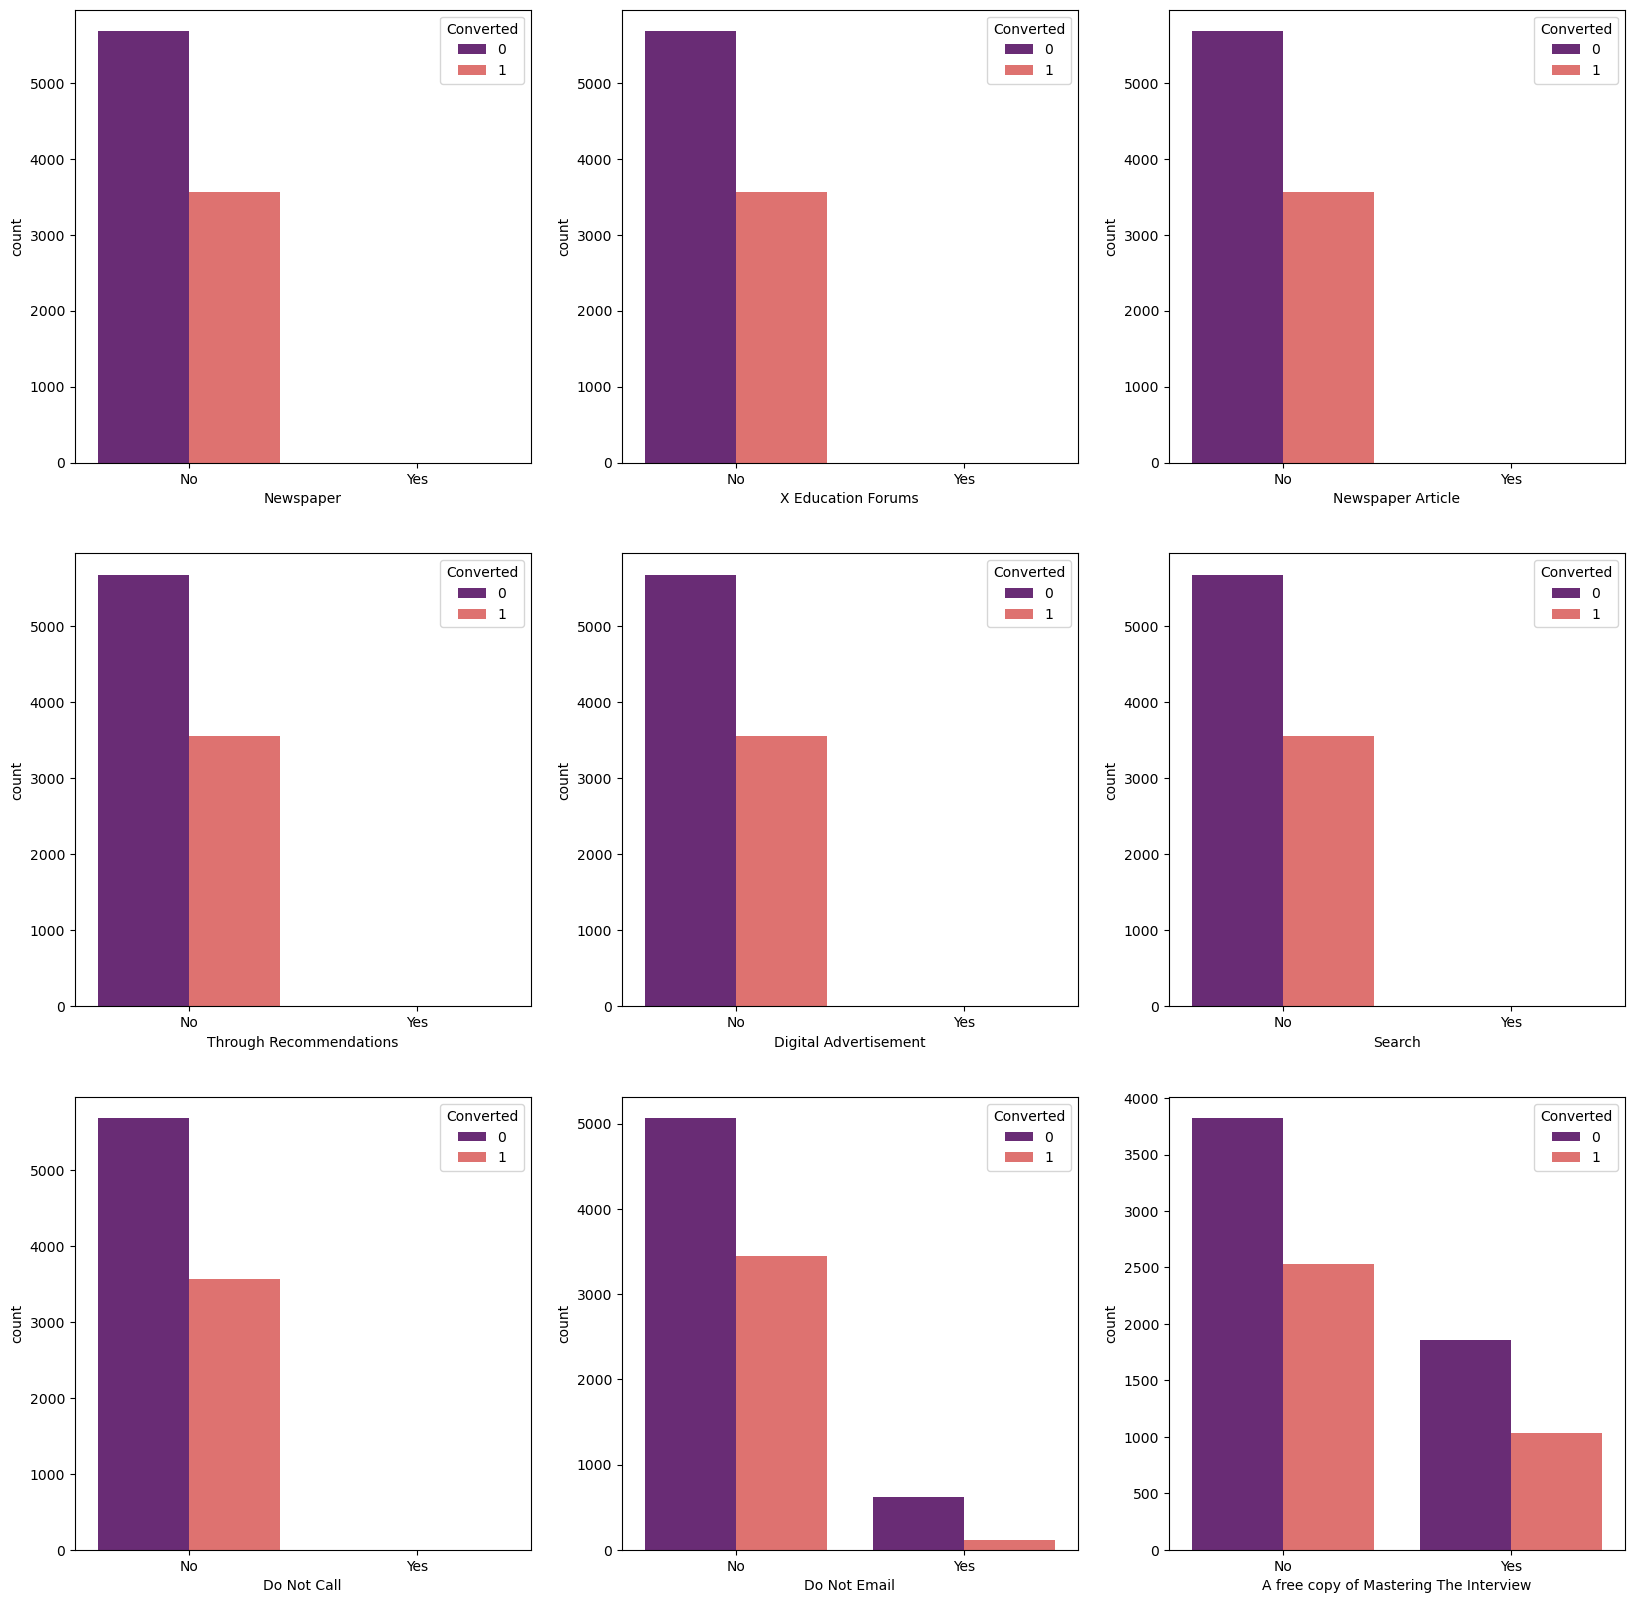

In [617]:
plt.figure(figsize=(20,20))
plt.subplot(331)
sns.countplot(data = df_leads, x=  'Newspaper', order=df_leads['Newspaper'].value_counts().index,hue = df_leads['Converted'],palette='magma')

plt.subplot(332)
sns.countplot(data = df_leads, x= 'X Education Forums', order=df_leads['X Education Forums'].value_counts().index,hue = df_leads['Converted'],palette='magma')

plt.subplot(333)
sns.countplot(data = df_leads, x=  'Newspaper Article', order=df_leads['Newspaper Article'].value_counts().index,hue = df_leads['Converted'],palette='magma')

plt.subplot(334)
sns.countplot(data = df_leads, x=  'Through Recommendations', order=df_leads['Through Recommendations'].value_counts().index,hue = df_leads['Converted'],palette='magma')

plt.subplot(335)
sns.countplot(data = df_leads, x=  'Digital Advertisement' , order=df_leads[ 'Digital Advertisement' ].value_counts().index,hue = df_leads['Converted'],palette='magma')

plt.subplot(336)
sns.countplot(data = df_leads, x= 'Search', order=df_leads['Search'].value_counts().index,hue = df_leads['Converted'],palette='magma')

plt.subplot(337)
sns.countplot(data = df_leads, x=  'Do Not Call', order=df_leads['Do Not Call'].value_counts().index,hue = df_leads['Converted'],palette='magma')

plt.subplot(338)
sns.countplot(data = df_leads, x=  'Do Not Email', order=df_leads['Do Not Email'].value_counts().index,hue = df_leads['Converted'],palette='magma')

plt.subplot(339)
sns.countplot(data = df_leads, x=  'A free copy of Mastering The Interview', order=df_leads['A free copy of Mastering The Interview'].value_counts().index,hue = df_leads['Converted'],palette='magma')



In [618]:
# dropping all below columns because all values have convertion
df_leads=df_leads.drop(["Newspaper","X Education Forums","Newspaper Article",
                          "Through Recommendations","Digital Advertisement",
                          "Search","Do Not Call"],axis=1)

In [619]:
categorical_columns = ['Lead Origin',
          'Lead Source',
          'Do Not Email',
          'Last Activity',
          'Country',
          'What is your current occupation',
          'A free copy of Mastering The Interview',
          'Last Notable Activity'
         ]

In [620]:
df_leads.shape

(9240, 14)

<Axes: xlabel='Lead Origin', ylabel='count'>

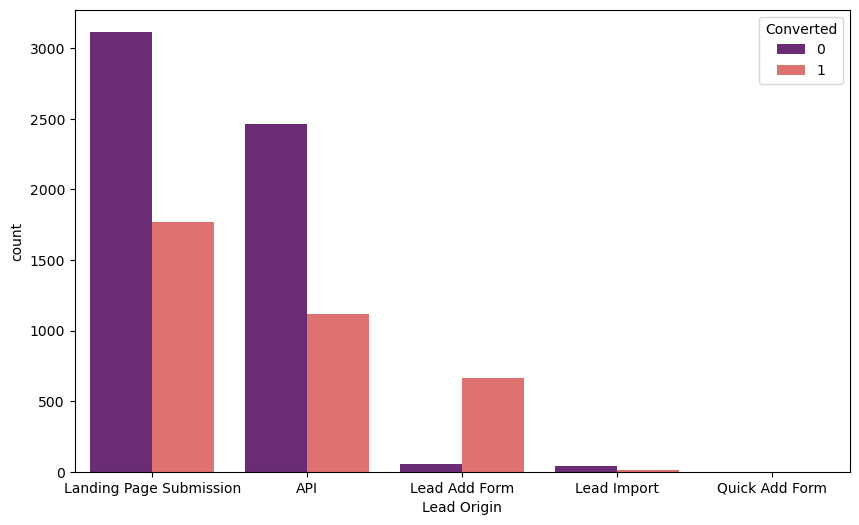

In [621]:
plt.figure(figsize = (10,6))
sns.countplot(data = df_leads, x= 'Lead Origin', order=df_leads['Lead Origin'].value_counts().index,hue = df_leads['Converted'],palette='magma')

<Axes: xlabel='Lead Source', ylabel='count'>

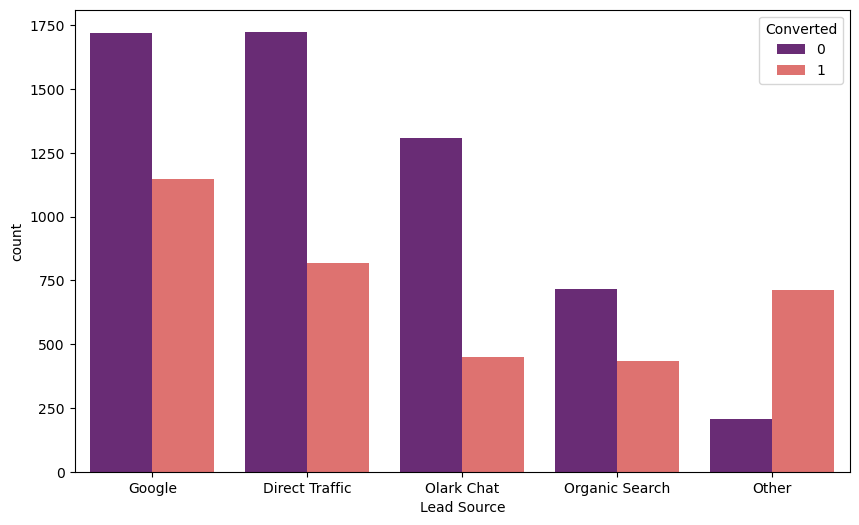

In [622]:
plt.figure(figsize = (10,6))
sns.countplot(data = df_leads, x= 'Lead Source', order=df_leads['Lead Source'].value_counts().index,hue = df_leads['Converted'],palette='magma')

<Axes: xlabel='Last Activity', ylabel='count'>

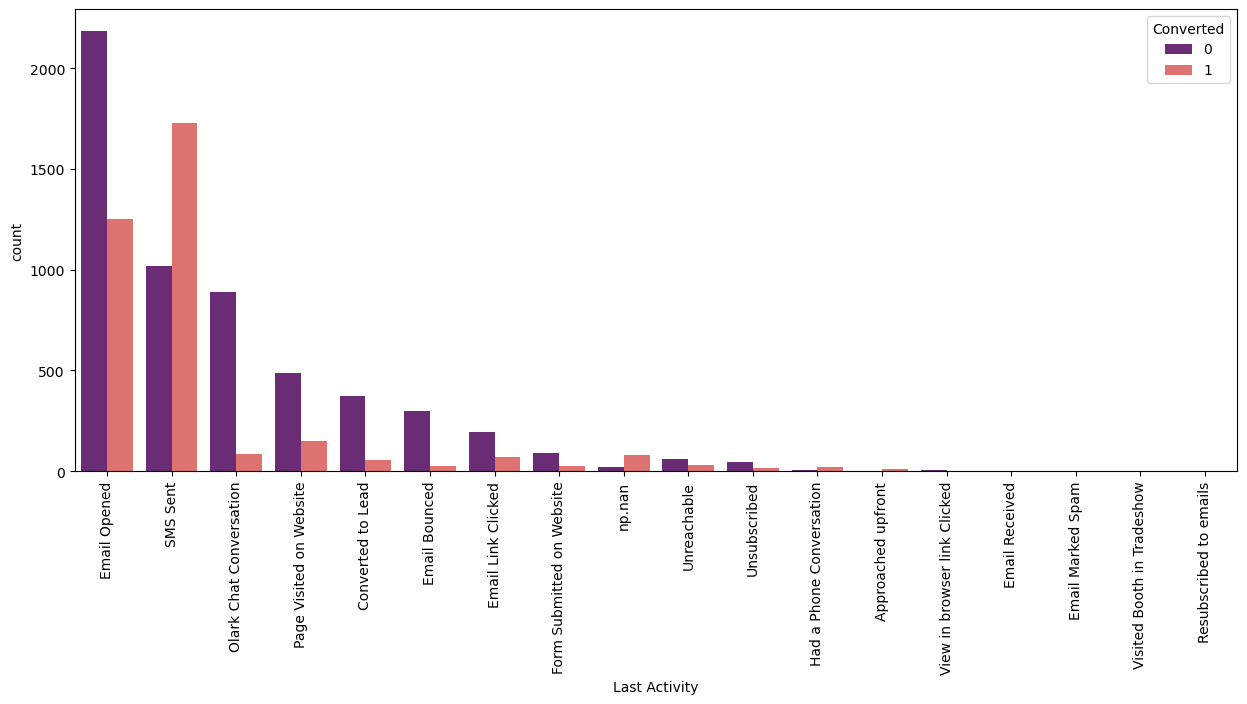

In [623]:
plt.figure(figsize = (15,6))
plt.xticks(rotation=90)
sns.countplot(data = df_leads, x= 'Last Activity', order=df_leads['Last Activity'].value_counts().index,hue = df_leads['Converted'],palette='magma')

In [624]:
df_leads[numerical_colmuns].describe(percentiles=[.25, .5, .75, .90, .95, .99])

,TotalVisits,Total Time Spent on Website,Page Views Per Visit
count,9240.000000,9240.000000,9240.000000
mean,3.438636,487.698268,2.357440
std,4.819024,548.021466,2.145781
min,0.000000,0.000000,0.000000
25%,1.000000,12.000000,1.000000
50%,3.000000,248.000000,2.000000
75%,5.000000,936.000000,3.000000
90%,7.000000,1380.000000,5.000000
95%,10.000000,1562.000000,6.000000
99%,17.000000,1840.610000,9.000000


<Axes: xlabel='Page Views Per Visit', ylabel='Density'>

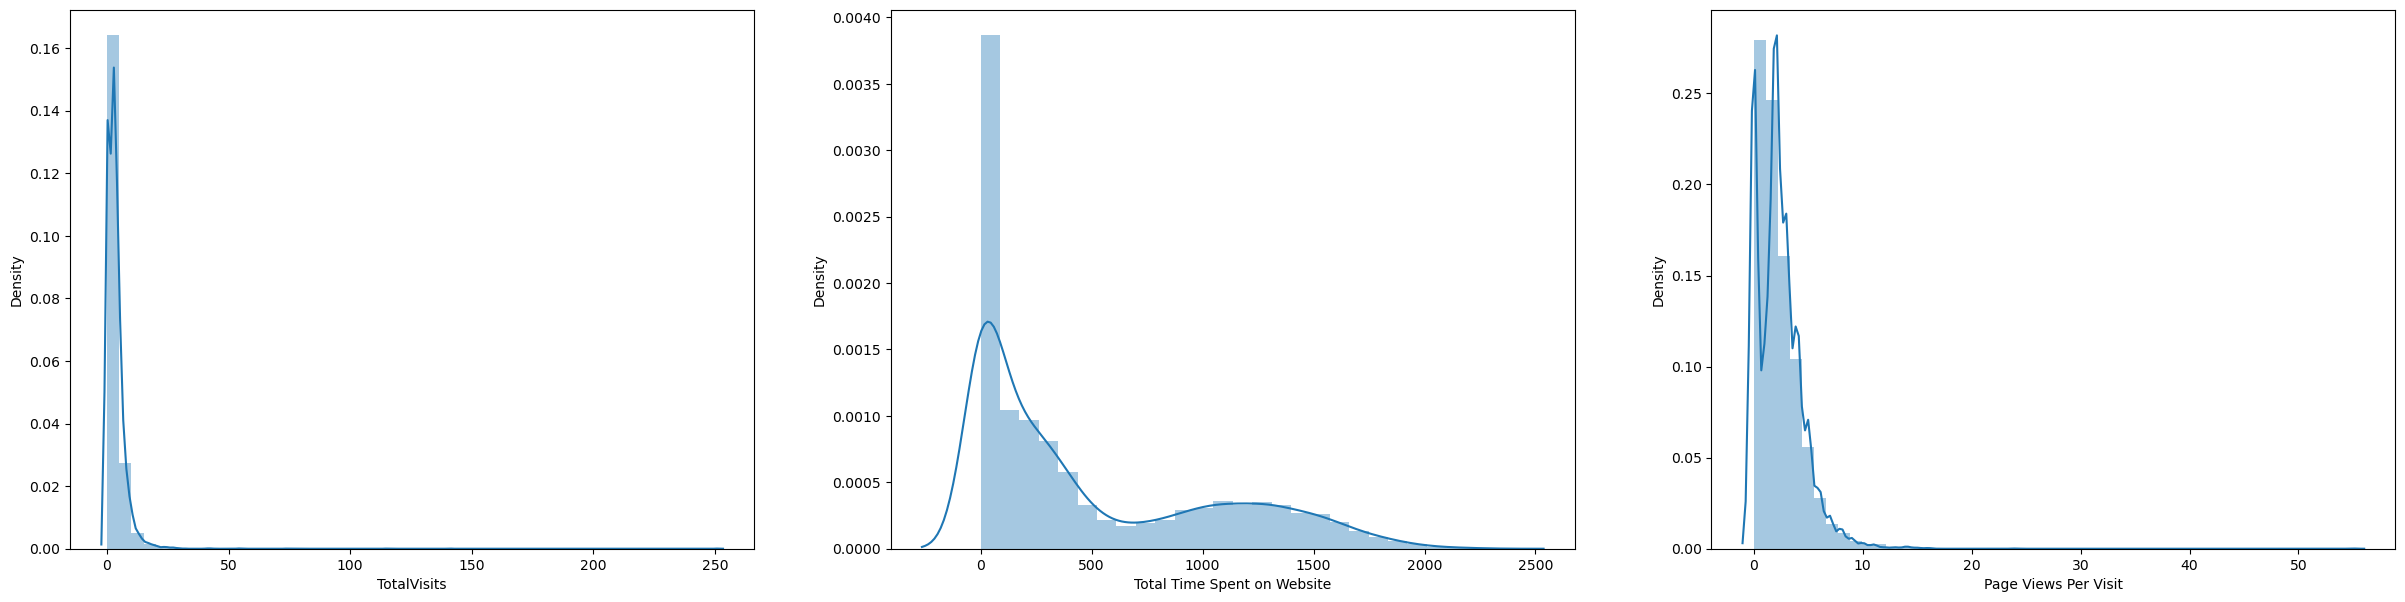

In [625]:
plt.figure(figsize =(30,7))
plt.subplot(1,3,1)
sns.distplot(df_leads['TotalVisits'])


plt.subplot(1,3,2)
sns.distplot(df_leads['Total Time Spent on Website'])


plt.subplot(1,3,3)
sns.distplot(df_leads['Page Views Per Visit'])

{'whiskers': [<matplotlib.lines.Line2D at 0x323c49310>,
 'caps': [<matplotlib.lines.Line2D at 0x323c49590>,
 'boxes': [<matplotlib.lines.Line2D at 0x323c491d0>],
 'medians': [<matplotlib.lines.Line2D at 0x323c49810>],
 'fliers': [<matplotlib.lines.Line2D at 0x323c49950>],
 'means': []}

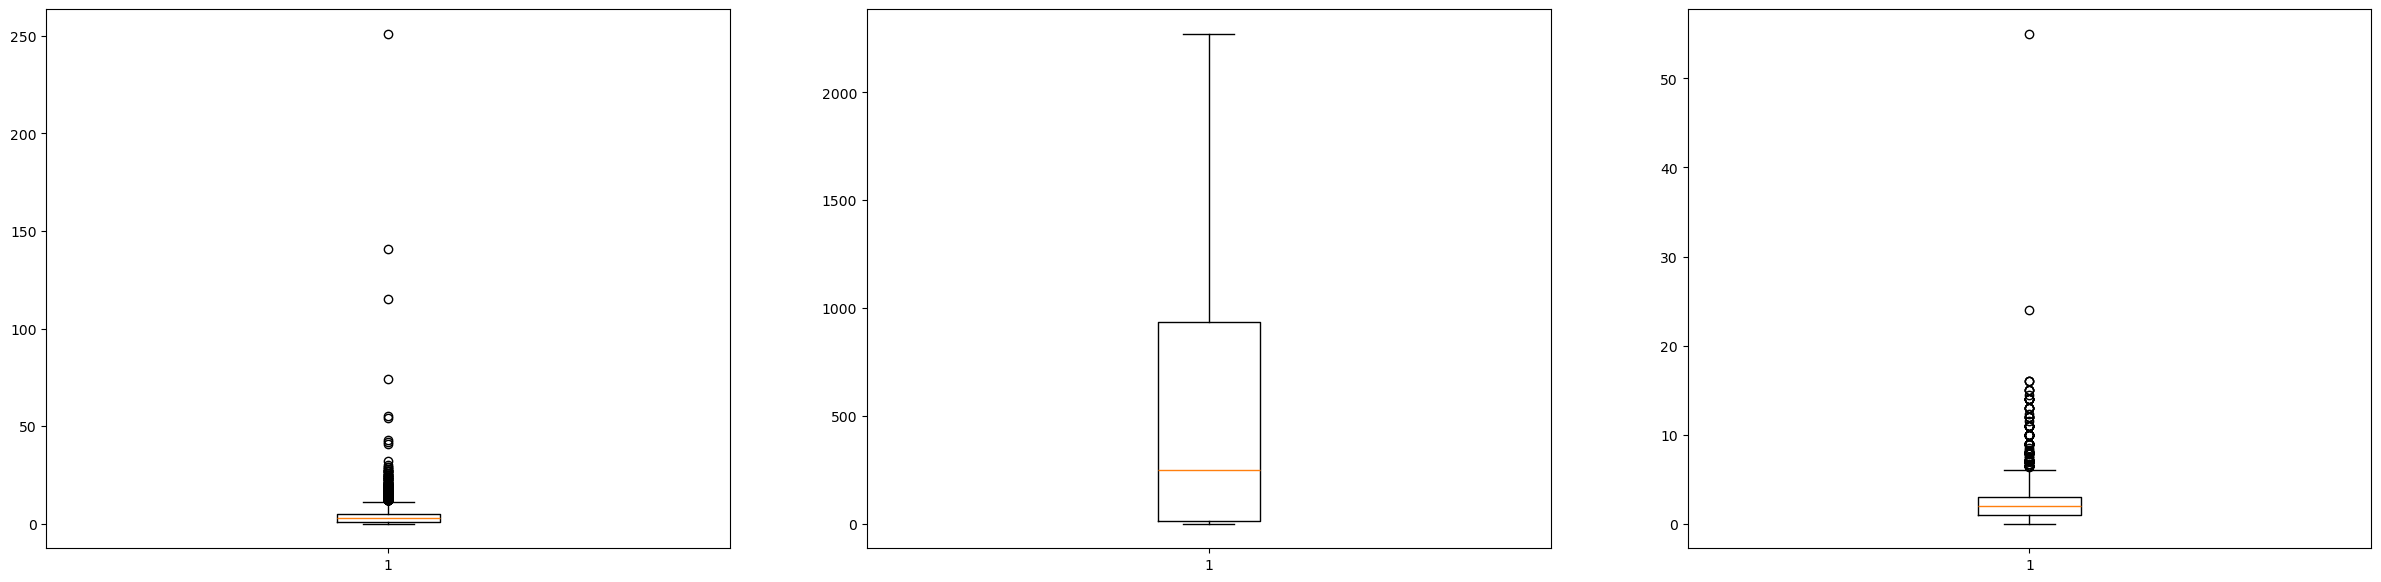

In [626]:
plt.figure(figsize =(30,7))
plt.subplot(1,3,1)
plt.boxplot(df_leads['TotalVisits'])


plt.subplot(1,3,2)
plt.boxplot(df_leads['Total Time Spent on Website'])


plt.subplot(1,3,3)
plt.boxplot(df_leads['Page Views Per Visit'])

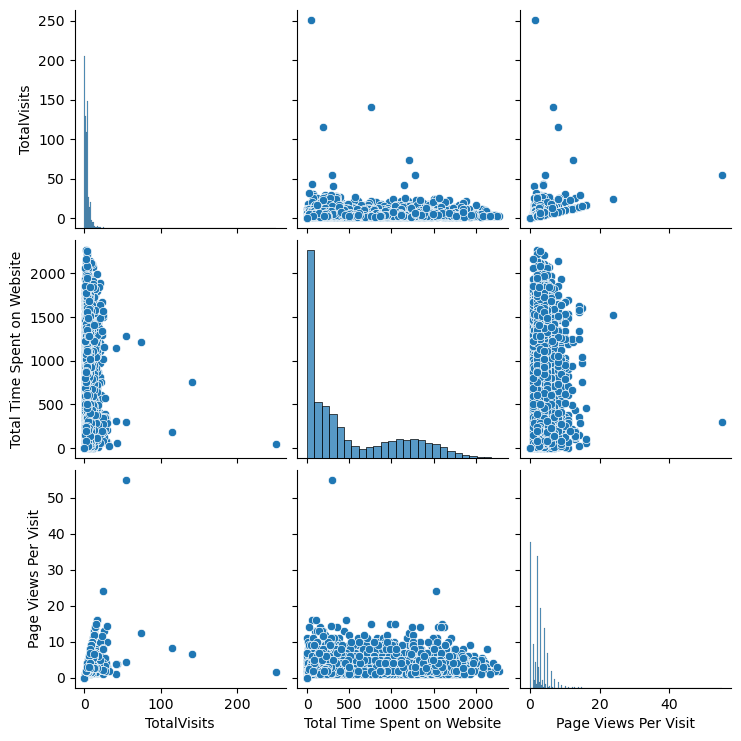

In [627]:
sns.pairplot(df_leads[numerical_colmuns])

In [628]:
df_leads.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,What is your current occupation,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,0,0.0,0,0.0,Page Visited on Website,India,Unemployed,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,0,5.0,674,2.5,Email Opened,India,Unemployed,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,1,2.0,1532,2.0,Email Opened,India,Student,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,0,1.0,305,1.0,Unreachable,India,Unemployed,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,1,2.0,1428,1.0,Converted to Lead,India,Unemployed,No,Modified


In [629]:
def binary_map(df):
    return df.map({'Yes': 1,'No': 0})

df_leads[['Do Not Email']] = df_leads[['Do Not Email']].apply(binary_map)


In [630]:
df_leads[['A free copy of Mastering The Interview']] = df_leads[['A free copy of Mastering The Interview']].apply(binary_map)
df_leads.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,What is your current occupation,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,0,0,0.0,0,0.0,Page Visited on Website,India,Unemployed,0,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,0,0,5.0,674,2.5,Email Opened,India,Unemployed,0,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,0,1,2.0,1532,2.0,Email Opened,India,Student,1,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,0,0,1.0,305,1.0,Unreachable,India,Unemployed,0,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,0,1,2.0,1428,1.0,Converted to Lead,India,Unemployed,0,Modified


In [631]:
categorical_columns = ['Lead Origin',
         'Lead Source',
         'Last Activity',
         'Country',
         'What is your current occupation',
         'Last Notable Activity']

In [632]:
# Creating a dummy variable for some of the categorical variables and dropping the first one.
dummy1 = pd.get_dummies(df_leads[categorical_columns], dtype=int, drop_first=True)

# Adding the results to the master dataframe
df_leads = pd.concat([df_leads, dummy1], axis=1)
df_leads.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,0,0,0.0,0,0.0,Page Visited on Website,...,0,0,1,0,0,0,0,0,0,0
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,0,0,5.0,674,2.5,Email Opened,...,0,0,0,0,0,0,0,0,0,0
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,0,1,2.0,1532,2.0,Email Opened,...,0,0,0,0,0,0,0,0,0,0
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,0,0,1.0,305,1.0,Unreachable,...,0,0,1,0,0,0,0,0,0,0
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,0,1,2.0,1428,1.0,Converted to Lead,...,0,0,1,0,0,0,0,0,0,0


In [633]:
df_leads.drop(labels=categorical_columns, inplace=True, axis=1)
df_leads.shape

(9240, 54)

In [634]:
df_leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 54 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Prospect ID                                           9240 non-null   object 
 1   Lead Number                                           9240 non-null   int64  
 2   Do Not Email                                          9240 non-null   int64  
 3   Converted                                             9240 non-null   int64  
 4   TotalVisits                                           9240 non-null   float64
 5   Total Time Spent on Website                           9240 non-null   int64  
 6   Page Views Per Visit                                  9240 non-null   float64
 7   A free copy of Mastering The Interview                9240 non-null   int64  
 8   Lead Origin_Landing Page Submission                   9240

In [635]:
numerical_colmuns

['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

In [636]:
numerical_colmuns = df_leads.iloc[:, 2:]
numerical_colmuns.head()

,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
0,0,0,0.0,0,0.0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,5.0,674,2.5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,2.0,1532,2.0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1.0,305,1.0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,1,2.0,1428,1.0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0


<Axes: >

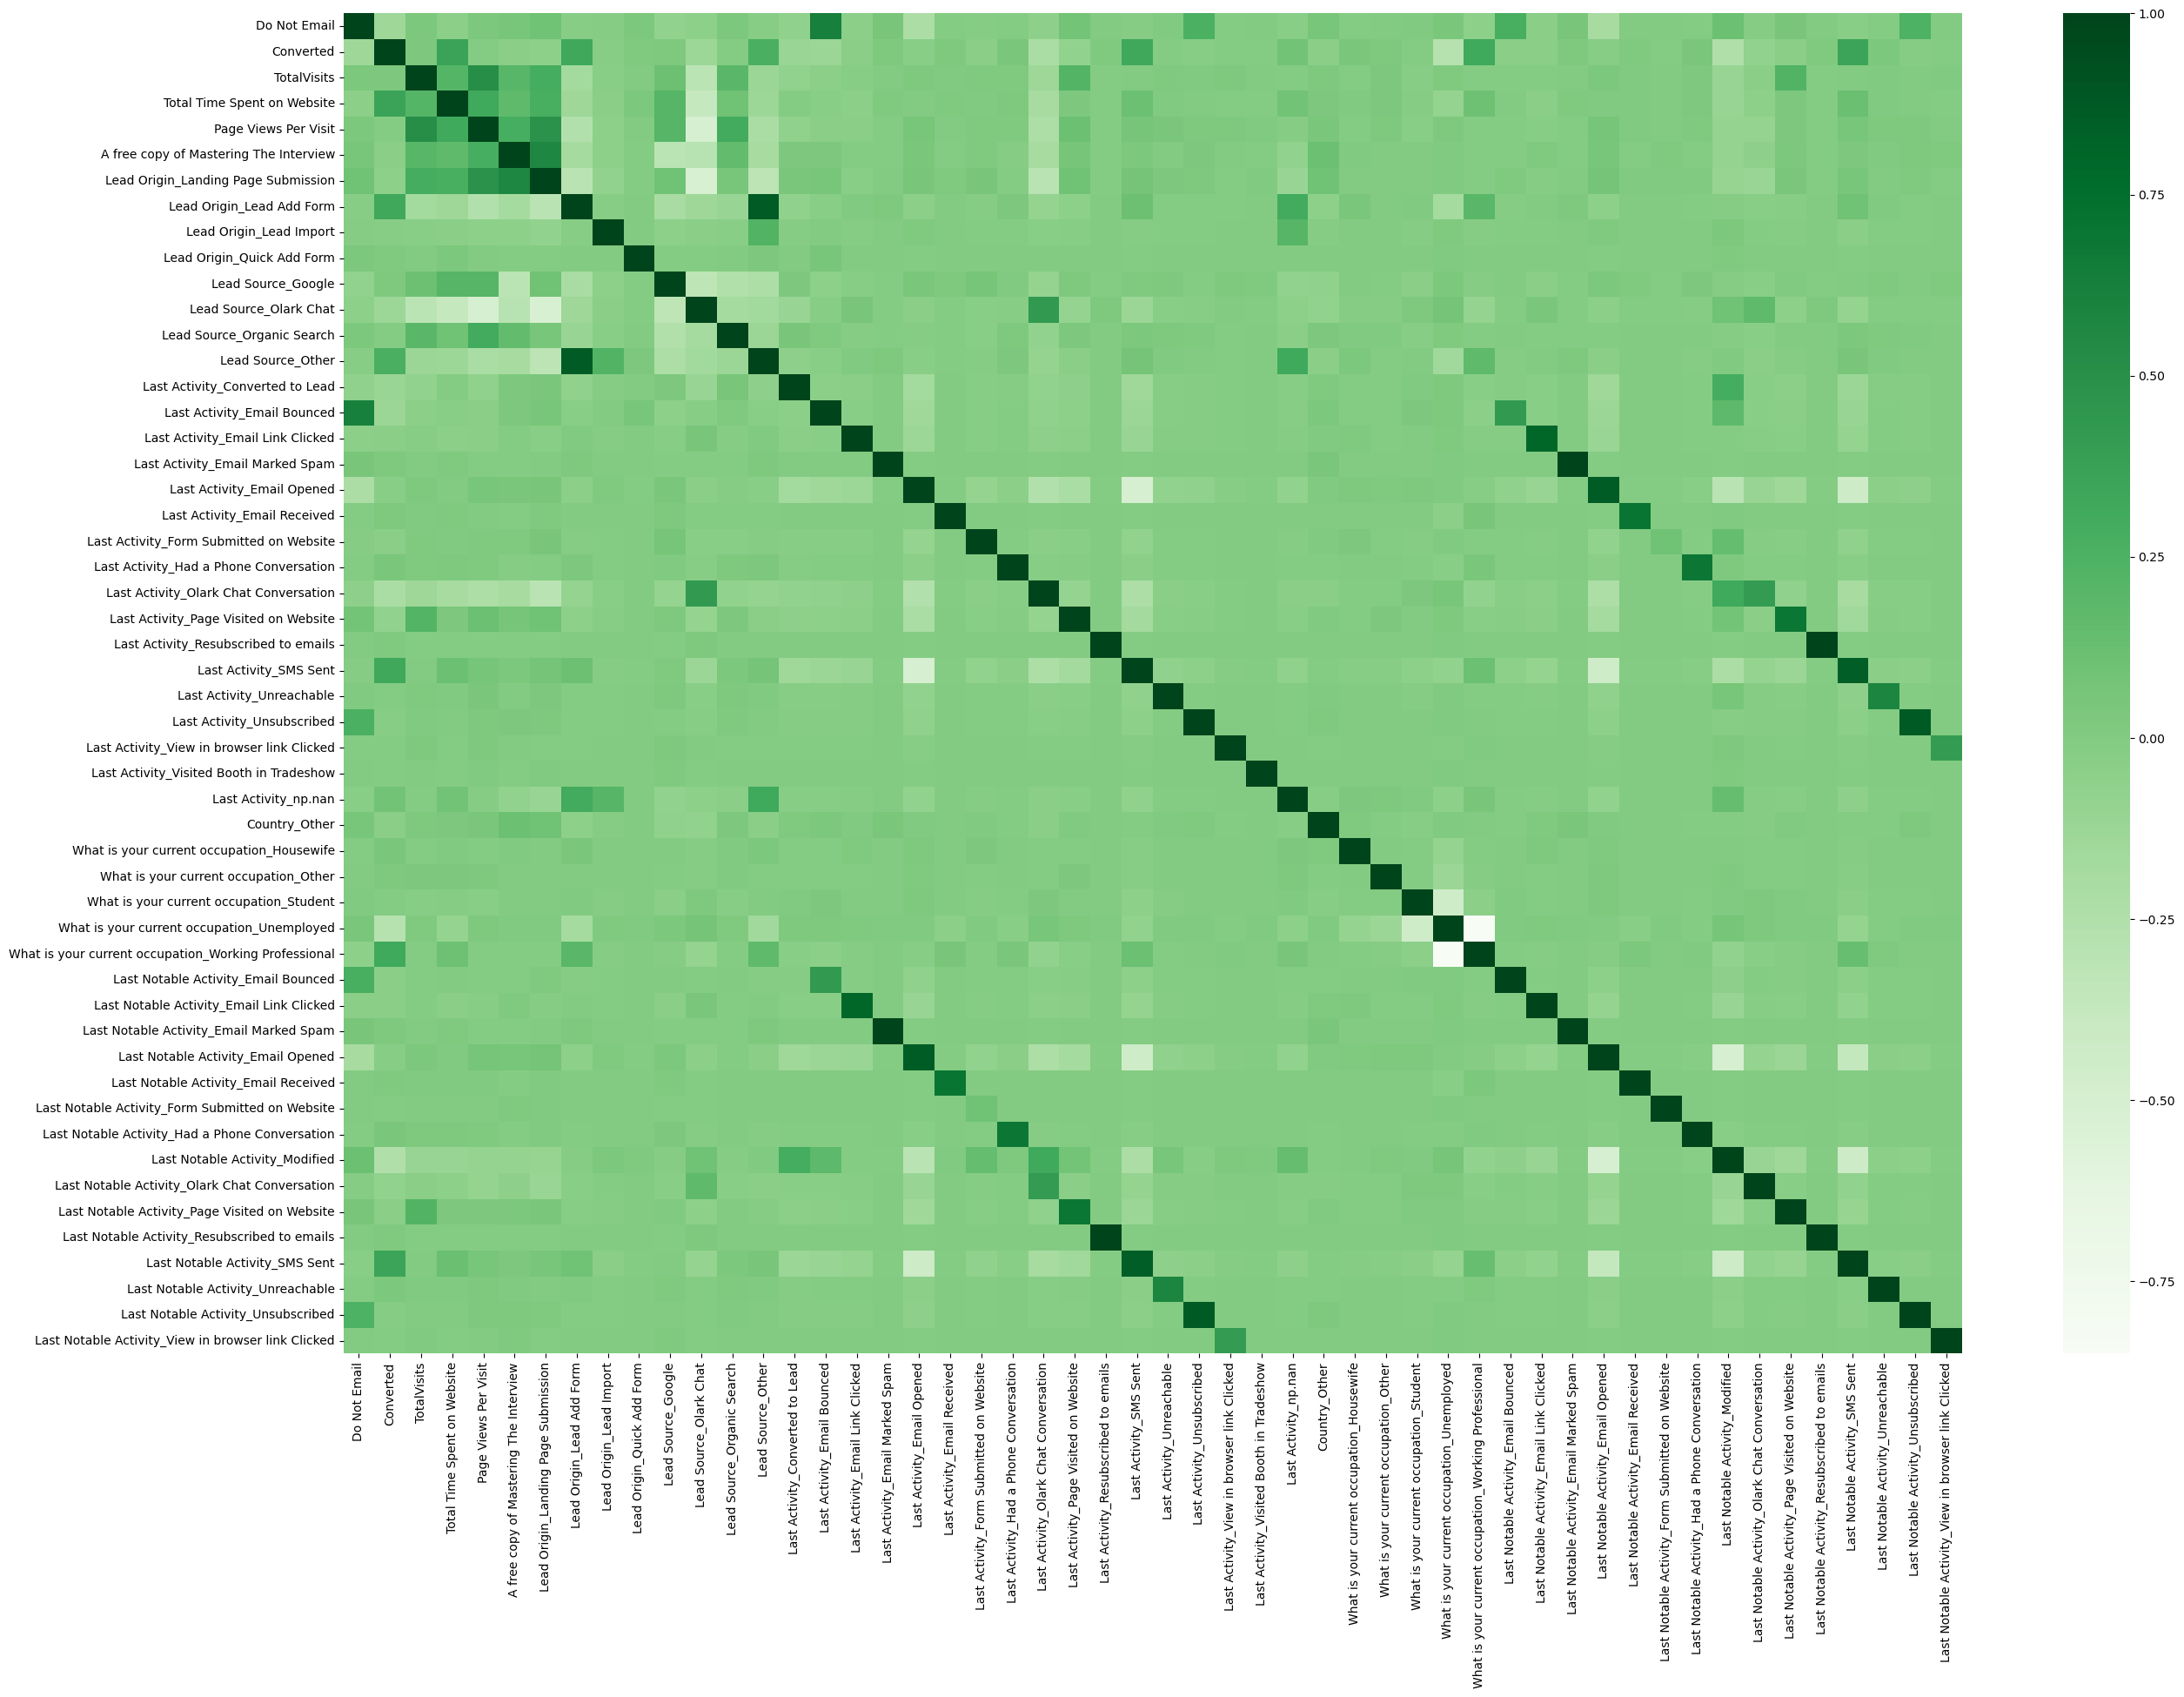

In [637]:
correlation = numerical_colmuns.corr()
plt.figure(figsize=(30,20))
sns.heatmap(correlation, annot = False, cmap = 'Greens')

In [638]:
correlation

,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
Do Not Email,1.000000,-0.135580,0.033640,-0.046374,0.033404,0.055762,0.095304,-0.020983,-0.017529,0.035416,...,-0.003056,-0.011443,0.117259,-0.013032,0.049921,-0.003056,-0.025990,-0.010505,0.243408,-0.003056
Converted,-0.135580,1.000000,0.029119,0.362483,-0.005068,-0.039820,-0.051236,0.321702,-0.023695,0.013138,...,-0.008238,0.043476,-0.244294,-0.072660,-0.036051,0.013138,0.351845,0.036594,-0.012858,-0.008238
TotalVisits,0.033640,0.029119,1.000000,0.217341,0.512214,0.202491,0.290871,-0.164679,-0.031862,-0.000947,...,-0.003106,0.022438,-0.106902,-0.037440,0.227865,-0.007424,-0.003163,0.005721,0.001068,0.009848
Total Time Spent on Website,-0.046374,0.362483,0.217341,1.000000,0.314266,0.168298,0.276009,-0.139681,-0.034926,0.032831,...,-0.003810,0.022261,-0.106857,-0.051402,0.026644,-0.009259,0.125076,0.008941,0.000503,-0.007569
Page Views Per Visit,0.033404,-0.005068,0.512214,0.314266,1.000000,0.277946,0.484385,-0.260746,-0.048300,-0.001733,...,-0.001733,0.014130,-0.096433,-0.087553,0.027158,-0.011431,0.056851,0.019723,0.018222,0.001516
A free copy of Mastering The Interview,0.055762,-0.039820,0.202491,0.168298,0.277946,1.000000,0.569633,-0.180893,-0.052178,-0.007015,...,0.015429,-0.008258,-0.084626,-0.057305,0.037921,-0.007015,0.028704,0.003967,0.020709,0.015429
Lead Origin_Landing Page Submission,0.095304,-0.051236,0.290871,0.276009,0.484385,0.569633,1.000000,-0.307485,-0.081974,-0.011021,...,0.009821,0.003328,-0.101822,-0.114790,0.046200,-0.011021,0.057507,0.000291,0.015686,-0.011021
Lead Origin_Lead Add Form,-0.020983,0.321702,-0.164679,-0.139681,-0.260746,-0.180893,-0.307485,1.000000,-0.022461,-0.003020,...,-0.003020,-0.011307,-0.013192,-0.029654,-0.023752,-0.003020,0.092690,0.003533,-0.009389,-0.003020
Lead Origin_Lead Import,-0.017529,-0.023695,-0.031862,-0.034926,-0.048300,-0.052178,-0.081974,-0.022461,1.000000,-0.000805,...,-0.000805,-0.003014,0.037095,-0.011000,-0.014609,-0.000805,-0.039579,-0.004562,-0.005533,-0.000805
Lead Origin_Quick Add Form,0.035416,0.013138,-0.000947,0.032831,-0.001733,-0.007015,-0.011021,-0.003020,-0.000805,1.000000,...,-0.000108,-0.000405,0.013613,-0.001479,-0.001964,-0.000108,-0.005767,-0.000613,-0.000744,-0.000108


In [639]:
df_leads.drop(labels=['Last Notable Activity_View in browser link Clicked'], axis=1, inplace=True)

In [640]:
high_corr_var = ['Lead Source_Other', 'Last Notable Activity_Email Marked Spam', 'Last Notable Activity_Email Link Clicked', 'Last Notable Activity_Email Opened',
                'Last Notable Activity_Email Received','Last Notable Activity_Had a Phone Conversation','Last Notable Activity_Page Visited on Website',
                'Last Notable Activity_Resubscribed to emails','Last Notable Activity_SMS Sent','Last Notable Activity_Unreachable','Last Notable Activity_Unsubscribed'
                ]

df_leads.drop(labels = high_corr_var, axis = 1, inplace = True)
df_leads.shape

(9240, 42)

In [641]:
df_leads.head()

,Prospect ID,Lead Number,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,...,Country_Other,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,0,0,0.0,0,0.0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,0,0,5.0,674,2.5,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,0,1,2.0,1532,2.0,1,1,0,...,0,0,0,1,0,0,0,0,0,0
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,0,0,1.0,305,1.0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
4,3256f628-e534-4826-9d63-4a8b88782852,660681,0,1,2.0,1428,1.0,0,1,0,...,0,0,0,0,1,0,0,0,1,0


In [642]:
# Putting feature variable to X
X = df_leads.drop(['Converted','Lead Number'], axis=1)
X = X.set_index('Prospect ID')
X.head()

,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,...,Country_Other,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation
Prospect ID,,,,,,,,,,,,,,,,,,,,,
7927b2df-8bba-4d29-b9a2-b6e0beafe620,0,0.0,0,0.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2a272436-5132-4136-86fa-dcc88c88f482,0,5.0,674,2.5,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
8cc8c611-a219-4f35-ad23-fdfd2656bd8a,0,2.0,1532,2.0,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
0cc2df48-7cf4-4e39-9de9-19797f9b38cc,0,1.0,305,1.0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
3256f628-e534-4826-9d63-4a8b88782852,0,2.0,1428,1.0,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,1,0


In [643]:
# Putting response variable to y
y = df_leads[['Prospect ID','Converted']]
y = y.set_index('Prospect ID')
y.head()

,Converted
Prospect ID,
7927b2df-8bba-4d29-b9a2-b6e0beafe620,0
2a272436-5132-4136-86fa-dcc88c88f482,0
8cc8c611-a219-4f35-ad23-fdfd2656bd8a,1
0cc2df48-7cf4-4e39-9de9-19797f9b38cc,0
3256f628-e534-4826-9d63-4a8b88782852,1


In [644]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [645]:
# Splitting the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [646]:
from sklearn.preprocessing import StandardScaler
scaler =  StandardScaler()

to_scale = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']
X_train[to_scale] = scaler.fit_transform(X_train[to_scale])
X_train.head()

,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,...,Country_Other,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation
Prospect ID,,,,,,,,,,,,,,,,,,,,,
f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0,-0.656434,-0.885371,-1.085519,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0,0.100767,0.005716,-0.470569,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
db308a34-ade6-4f0d-9779-586c5be188c7,0,0.290067,-0.691418,0.070401,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1199b37d-f610-4bb8-bf18-15267dec61fa,0,0.290067,1.365219,1.226321,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
6b2d3b2f-9990-449c-9333-012b578e39c8,0,-0.656434,-0.885371,-1.085519,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


### Modeling

In [647]:
import statsmodels.api as sm

In [651]:
# X_train_sm = sm.add_constant(X_train)
# sm_model = sm.Logit(y_train, X_train).fit()


logm1 = sm.GLM(y_train,(sm.add_constant(X_train)), family = sm.families.Binomial())
logm1.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6428
Model Family:                Binomial   Df Model:                           39
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2663.3
Date:                Fri, 02 Jan 2026   Deviance:                       5326.7
Time:                        10:15:57   Pearson chi2:                 8.86e+03
No. Iterations:                    22   Pseudo R-squ. (CS):             0.3970
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   22.7361    2.6e+04      0.001      0.999    -5.1e+04     5.1e+04
Do Not Email                                            -1.2036      0.217     -5.555      0.000      -1.628      -0.779
TotalVisits                                              0.1885      0.050      3.740      0.000       0.090       0.287
Total Time Spent on Website                              1.0922      0.040     27.394      0.000       1.014       1.170
Page Views Per Visit                                    -0.1186      0.053     -2.254      0.024      -0.222      -0.015
A free copy of Mastering The Interview                  -0.0199      0.104     -0.192      0.848      -0.223       0.183
Lead Origin_Landing Page Submission                     -0.1760      0.104     -1.698      0.089      -0.379       0.027
Lead Origin_Lead Add Form                                4.0782      0.230     17.714      0.000       3.627       4.529
Lead Origin_Lead Import                                  0.2969      0.533      0.557      0.578      -0.748       1.342
Lead Origin_Quick Add Form                              24.3693   7.95e+04      0.000      1.000   -1.56e+05    1.56e+05
Lead Source_Google                                       0.3201      0.108      2.958      0.003       0.108       0.532
Lead Source_Olark Chat                                   1.1541      0.155      7.447      0.000       0.850       1.458
Lead Source_Organic Search                               0.1513      0.125      1.208      0.227      -0.094       0.397
Last Activity_Converted to Lead                        -24.2321    2.6e+04     -0.001      0.999    -5.1e+04     5.1e+04
Last Activity_Email Bounced                            -24.6536    2.6e+04     -0.001      0.999    -5.1e+04     5.1e+04
Last Activity_Email Link Clicked                       -24.0221    2.6e+04     -0.001      0.999    -5.1e+04     5.1e+04
Last Activity_Email Marked Spam                         -0.1869   8.36e+04  -2.24e-06      1.000   -1.64e+05    1.64e+05
Last Activity_Email Opened                             -23.5650    2.6e+04     -0.001      0.999    -5.1e+04     5.1e+04
Last Activity_Email Received                            -2.5173   6.18e+04  -4.07e-05      1.000   -1.21e+05    1.21e+05
Last Activity_Form Submitted on Website                -23.6360    2.6e+04     -0.001      0.999    -5.1e+04     5.1e+04
Last Activity_Had a Phone Conversation                 -21.3564    2.6e+04     -0.001      0.999    -5.1e+04     5.1e+04
Last Activity_Olark Chat Conversation                  -24.5007    2.6e+04     -0.001      0.999    -5.1e+04     5.1e+04
Last Activity_Page Visited on Website                  -23

In [653]:
# Create an instance of the logistic regression model
log_reg = LogisticRegression()

from sklearn.feature_selection import RFE
rfe = RFE(log_reg)             # running RFE with 20 variables as output
rfe = rfe.fit(X_train, y_train)

In [654]:
list(zip(X_train.columns, rfe.support_, rfe.ranking_))

[('Do Not Email', np.True_, np.int64(1)),
 ('TotalVisits', np.False_, np.int64(11)),
 ('Total Time Spent on Website', np.True_, np.int64(1)),
 ('Page Views Per Visit', np.False_, np.int64(16)),
 ('A free copy of Mastering The Interview', np.False_, np.int64(21)),
 ('Lead Origin_Landing Page Submission', np.False_, np.int64(5)),
 ('Lead Origin_Lead Add Form', np.True_, np.int64(1)),
 ('Lead Origin_Lead Import', np.False_, np.int64(10)),
 ('Lead Origin_Quick Add Form', np.False_, np.int64(7)),
 ('Lead Source_Google', np.False_, np.int64(9)),
 ('Lead Source_Olark Chat', np.True_, np.int64(1)),
 ('Lead Source_Organic Search', np.False_, np.int64(15)),
 ('Last Activity_Converted to Lead', np.True_, np.int64(1)),
 ('Last Activity_Email Bounced', np.True_, np.int64(1)),
 ('Last Activity_Email Link Clicked', np.False_, np.int64(3)),
 ('Last Activity_Email Marked Spam', np.False_, np.int64(8)),
 ('Last Activity_Email Opened', np.False_, np.int64(14)),
 ('Last Activity_Email Received', np.False_

In [655]:
col = X_train.columns[rfe.support_]
col

Index(['Do Not Email', 'Total Time Spent on Website',
       'Lead Origin_Lead Add Form', 'Lead Source_Olark Chat',
       'Last Activity_Converted to Lead', 'Last Activity_Email Bounced',
       'Last Activity_Had a Phone Conversation',
       'Last Activity_Olark Chat Conversation', 'Last Activity_SMS Sent',
       'Last Activity_Unsubscribed', 'Last Activity_np.nan',
       'What is your current occupation_Housewife',
       'What is your current occupation_Other',
       'What is your current occupation_Student',
       'What is your current occupation_Unemployed',
       'What is your current occupation_Working Professional',
       'Last Notable Activity_Email Bounced', 'Last Notable Activity_Modified',
       'Last Notable Activity_Olark Chat Conversation'],
      dtype='object')

In [656]:
X_train.columns[~rfe.support_]

Index(['TotalVisits', 'Page Views Per Visit',
       'A free copy of Mastering The Interview',
       'Lead Origin_Landing Page Submission', 'Lead Origin_Lead Import',
       'Lead Origin_Quick Add Form', 'Lead Source_Google',
       'Lead Source_Organic Search', 'Last Activity_Email Link Clicked',
       'Last Activity_Email Marked Spam', 'Last Activity_Email Opened',
       'Last Activity_Email Received',
       'Last Activity_Form Submitted on Website',
       'Last Activity_Page Visited on Website',
       'Last Activity_Resubscribed to emails', 'Last Activity_Unreachable',
       'Last Activity_View in browser link Clicked',
       'Last Activity_Visited Booth in Tradeshow', 'Country_Other',
       'Last Notable Activity_Form Submitted on Website'],
      dtype='object')

In [657]:
X_train_sm = sm.add_constant(X_train[col])
logm2 = sm.GLM(y_train,X_train_sm, family = sm.families.Binomial())
res = logm2.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6448
Model Family:                Binomial   Df Model:                           19
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2698.5
Date:                Fri, 02 Jan 2026   Deviance:                       5396.9
Time:                        10:23:47   Pearson chi2:                 8.93e+03
No. Iterations:                    21   Pseudo R-squ. (CS):             0.3904
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   -0.7463      1.088     -0.686      0.493      -2.879       1.387
Do Not Email                                            -1.2126      0.207     -5.855      0.000      -1.618      -0.807
Total Time Spent on Website                              1.0980      0.039     27.883      0.000       1.021       1.175
Lead Origin_Lead Add Form                                4.0669      0.196     20.791      0.000       3.684       4.450
Lead Source_Olark Chat                                   1.1376      0.102     11.167      0.000       0.938       1.337
Last Activity_Converted to Lead                         -0.6350      0.229     -2.770      0.006      -1.084      -0.186
Last Activity_Email Bounced                             -0.9641      0.446     -2.164      0.030      -1.837      -0.091
Last Activity_Had a Phone Conversation                   2.3330      0.676      3.452      0.001       1.008       3.658
Last Activity_Olark Chat Conversation                   -0.8241      0.197     -4.189      0.000      -1.210      -0.438
Last Activity_SMS Sent                                   1.1906      0.075     15.908      0.000       1.044       1.337
Last Activity_Unsubscribed                               0.5747      0.502      1.146      0.252      -0.408       1.558
Last Activity_np.nan                                    -0.9439      0.448     -2.106      0.035      -1.822      -0.066
What is your current occupation_Housewife               22.5681   1.36e+04      0.002      0.999   -2.65e+04    2.66e+04
What is your current occupation_Other                   -0.2567      1.343     -0.191      0.848      -2.888       2.375
What is your current occupation_Student                 -0.0997      1.113     -0.090      0.929      -2.280       2.081
What is your current occupation_Unemployed              -0.4658      1.088     -0.428      0.669      -2.599       1.667
What is your current occupation_Working Professional     2.3559      1.103      2.135      0.033       0.193       4.519
Last Notable Activity_Email Bounced                      1.2158      0.609      1.996      0.046       0.022       2.410
Last Notable Activity_Modified                          -0.8000      0.088     -9.064      0.000      -0.973      -0.627
Last Notable Activity_Olark Chat Conversation           -0.5432      0.371     -1.463      0.144      -1.271       0.185
========================================================================================================================
"""

In [658]:
# Check for the VIF values of the feature variables.
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = X_train[col].columns
vif['VIF'] = [variance_inflation_factor(X_train[col].values, i) for i in range(X_train[col].shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
14,What is your current occupation_Unemployed,2.67
17,Last Notable Activity_Modified,2.51
5,Last Activity_Email Bounced,2.17
0,Do Not Email,2.07
7,Last Activity_Olark Chat Conversation,2.05
3,Lead Source_Olark Chat,1.78
8,Last Activity_SMS Sent,1.69
2,Lead Origin_Lead Add Form,1.39
18,Last Notable Activity_Olark Chat Conversation,1.35
1,Total Time Spent on Website,1.29


In [659]:
# Getting the predicted values on the train set
y_train_pred = res.predict(X_train_sm)
y_train_pred.head()

Prospect ID
f3af2d98-02db-45d7-bbf6-c641d6b4f4c3    0.259877
207aaf73-a121-41b8-96bb-b0d5c38e7a7b    0.230439
db308a34-ade6-4f0d-9779-586c5be188c7    0.302874
1199b37d-f610-4bb8-bf18-15267dec61fa    0.814197
6b2d3b2f-9990-449c-9333-012b578e39c8    0.136268
dtype: float64

In [660]:
y_train_pred = pd.DataFrame({'Prospect ID':y_train_pred.index, 'Converted_Prob':y_train_pred.values})
y_train_pred.head()

,Prospect ID,Converted_Prob
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0.259877
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0.230439
2,db308a34-ade6-4f0d-9779-586c5be188c7,0.302874
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0.814197
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0.136268


In [661]:
y_train.head()

,Converted
Prospect ID,
f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0
207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0
db308a34-ade6-4f0d-9779-586c5be188c7,0
1199b37d-f610-4bb8-bf18-15267dec61fa,0
6b2d3b2f-9990-449c-9333-012b578e39c8,0


In [662]:
y_train_pred.shape

(6468, 2)

In [663]:
y_train = y_train.reset_index()
y_train.head()

,Prospect ID,Converted
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0
2,db308a34-ade6-4f0d-9779-586c5be188c7,0
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0


In [664]:
y_train_pred_final = pd.merge(y_train, y_train_pred, how='inner', on='Prospect ID')
y_train_pred_final.head()

,Prospect ID,Converted,Converted_Prob
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0,0.259877
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0,0.230439
2,db308a34-ade6-4f0d-9779-586c5be188c7,0,0.302874
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0,0.814197
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0,0.136268


In [665]:
y_train_pred_final['predicted'] = y_train_pred_final.Converted_Prob.map(lambda x: 1 if x > 0.5 else 0)

# Let's see the head
y_train_pred_final.head()

,Prospect ID,Converted,Converted_Prob,predicted
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0,0.259877,0
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0,0.230439,0
2,db308a34-ade6-4f0d-9779-586c5be188c7,0,0.302874,0
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0,0.814197,1
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0,0.136268,0


In [666]:
from sklearn import metrics

In [667]:
# Confusion matrix
confusion = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.predicted )
print(confusion)

[[3555  447]
 [ 734 1732]]


In [668]:
# Let's check the overall accuracy.
print(metrics.accuracy_score(y_train_pred_final.Converted, y_train_pred_final.predicted))

0.8174087816944959


In [669]:
TP = confusion[1,1] # true positive
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [670]:
# Let's see the sensitivity of our logistic regression model
TP / float(TP+FN)

np.float64(0.7023519870235199)

In [671]:
# Calculate false postive rate - predicting conversion when customer did not convert
print(FP/ float(TN+FP))

0.11169415292353824


In [672]:
# positive predictive value
print (TP / float(TP+FP))

0.7948600275355667


In [673]:
# Negative predictive value
print (TN / float(TN+ FN))

0.8288645371881558


#### ROC Curve

In [674]:
def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

In [675]:
fpr, tpr, thresholds = metrics.roc_curve( y_train_pred_final.Converted, y_train_pred_final.Converted_Prob, drop_intermediate = False )

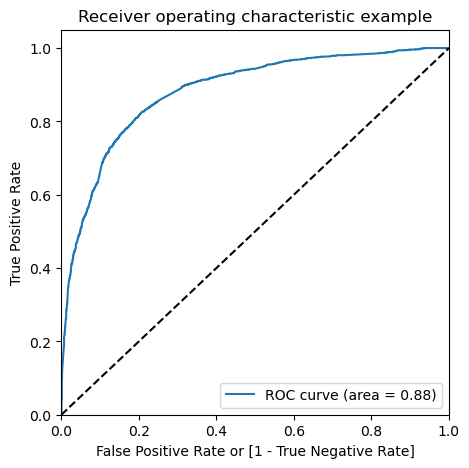

In [676]:
draw_roc(y_train_pred_final.Converted, y_train_pred_final.Converted_Prob)

In [677]:
# Let's create columns with different probability cutoffs
numbers = [float(x)/10 for x in range(10)]
for i in numbers:
    y_train_pred_final[i]= y_train_pred_final.Converted_Prob.map(lambda x: 1 if x > i else 0)
y_train_pred_final.head()

,Prospect ID,Converted,Converted_Prob,predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0,0.259877,0,1,1,1,0,0,0,0,0,0,0
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0,0.230439,0,1,1,1,0,0,0,0,0,0,0
2,db308a34-ade6-4f0d-9779-586c5be188c7,0,0.302874,0,1,1,1,1,0,0,0,0,0,0
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0,0.814197,1,1,1,1,1,1,1,1,1,1,0
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0,0.136268,0,1,1,0,0,0,0,0,0,0,0


In [678]:
# Now let's calculate accuracy sensitivity and specificity for various probability cutoffs.
cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])
from sklearn.metrics import confusion_matrix

# TP = confusion[1,1] # true positive
# TN = confusion[0,0] # true negatives
# FP = confusion[0,1] # false positives
# FN = confusion[1,0] # false negatives

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    cm1 = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final[i] )
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1

    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])
    cutoff_df.loc[i] =[ i ,accuracy,sensi,speci]
print(cutoff_df)

     prob  accuracy     sensi     speci
0.0   0.0  0.381262  1.000000  0.000000
0.1   0.1  0.586271  0.974047  0.347326
0.2   0.2  0.743043  0.912409  0.638681
0.3   0.3  0.800711  0.833333  0.780610
0.4   0.4  0.816172  0.759935  0.850825
0.5   0.5  0.817409  0.702352  0.888306
0.6   0.6  0.797619  0.594079  0.923038
0.7   0.7  0.783241  0.517437  0.947026
0.8   0.8  0.761596  0.421736  0.971014
0.9   0.9  0.712276  0.264801  0.988006


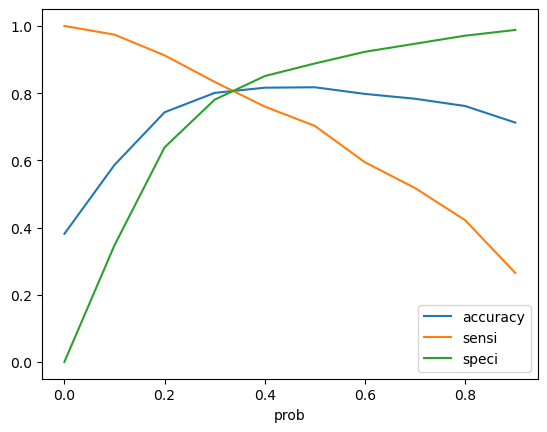

In [679]:
# Let's plot accuracy sensitivity and specificity for various probabilities.
cutoff_df.plot.line(x='prob', y=['accuracy','sensi','speci'])
plt.show()

In [680]:
y_train_pred_final['final_predicted'] = y_train_pred_final.Converted_Prob.map( lambda x: 1 if x > 0.35 else 0)

y_train_pred_final.head()

,Prospect ID,Converted,Converted_Prob,predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,final_predicted
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0,0.259877,0,1,1,1,0,0,0,0,0,0,0,0
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0,0.230439,0,1,1,1,0,0,0,0,0,0,0,0
2,db308a34-ade6-4f0d-9779-586c5be188c7,0,0.302874,0,1,1,1,1,0,0,0,0,0,0,0
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0,0.814197,1,1,1,1,1,1,1,1,1,1,0,1
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0,0.136268,0,1,1,0,0,0,0,0,0,0,0,0


In [681]:
# Let's check the overall accuracy.
metrics.accuracy_score(y_train_pred_final.Converted, y_train_pred_final.final_predicted)

0.8095238095238095

In [682]:
confusion2 = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.final_predicted )
confusion2

array([[3281,  721],
       [ 511, 1955]])

In [683]:
TP = confusion2[1,1] # true positive
TN = confusion2[0,0] # true negatives
FP = confusion2[0,1] # false positives
FN = confusion2[1,0] # false negatives

In [684]:
# Let's see the sensitivity of our logistic regression model
TP / float(TP+FN)

np.float64(0.7927818329278183)

In [685]:
# Let us calculate specificity
TN / float(TN+FP)

np.float64(0.81984007996002)

In [686]:
# Calculate false postive rate - predicting how many leads converted
#when customer does not have converted
print(FP/ float(TN+FP))

0.18015992003998002


In [687]:
# Positive predictive value
print (TP / float(TP+FP))

0.7305680119581465


In [688]:
# Negative predictive value
print (TN / float(TN+ FN))

0.8652426160337553


In [689]:
y_train_pred_final.shape

(6468, 15)

In [690]:
from sklearn.metrics import precision_recall_curve

In [691]:
y_train_pred_final.Converted, y_train_pred_final.predicted

(0       0
 1       0
 2       0
 3       0
 4       0
        ..
 6463    1
 6464    1
 6465    1
 6466    0
 6467    0
 Name: Converted, Length: 6468, dtype: int64,
 0       0
 1       0
 2       0
 3       1
 4       0
        ..
 6463    1
 6464    1
 6465    0
 6466    0
 6467    0
 Name: predicted, Length: 6468, dtype: int64)

In [692]:
p, r, thresholds = precision_recall_curve(y_train_pred_final.Converted, y_train_pred_final.Converted_Prob)

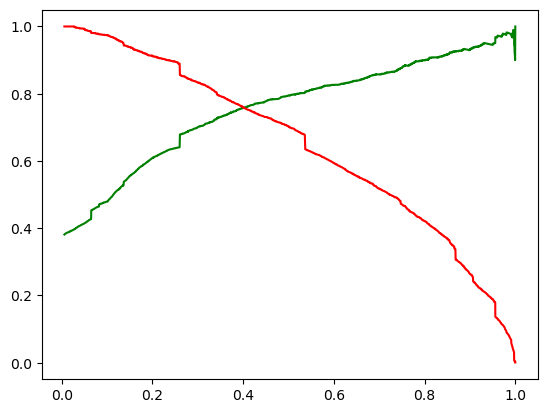

In [693]:
plt.plot(thresholds, p[:-1], "g-")
plt.plot(thresholds, r[:-1], "r-")

In [694]:
Recall = TP / float(TP+FN)
Recall

np.float64(0.7927818329278183)

In [695]:
Precision = TP / float(TP+FP)
Precision

np.float64(0.7305680119581465)

In [696]:
F1_score = (2* Recall * Precision)/ (Recall+Precision)
F1_score

np.float64(0.7604045118630883)

In [697]:
X_test.head()

,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,...,Country_Other,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation
Prospect ID,,,,,,,,,,,,,,,,,,,,,
dd53b3eb-ae22-474c-b872-48b05bbe180b,0,8.0,1011,8.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
7a960b03-466c-4e36-bf12-b755fc77a0b1,0,0.0,0,0.0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,0,5.0,59,5.0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0,0.0,0,0.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
f7ed6c72-7d36-413c-b2e0-414213c4ceef,0,0.0,0,0.0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [698]:
X_test[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']] = scaler.transform(X_test[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']])
X_test.head()

,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,...,Country_Other,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation
Prospect ID,,,,,,,,,,,,,,,,,,,,,
dd53b3eb-ae22-474c-b872-48b05bbe180b,0,0.857967,0.964504,2.613424,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
7a960b03-466c-4e36-bf12-b755fc77a0b1,0,-0.656434,-0.885371,-1.085519,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,0,0.290067,-0.777416,1.226321,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0,-0.656434,-0.885371,-1.085519,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
f7ed6c72-7d36-413c-b2e0-414213c4ceef,0,-0.656434,-0.885371,-1.085519,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [699]:
X_test = X_test[col]
X_test.head()

,Do Not Email,Total Time Spent on Website,Lead Origin_Lead Add Form,Lead Source_Olark Chat,Last Activity_Converted to Lead,Last Activity_Email Bounced,Last Activity_Had a Phone Conversation,Last Activity_Olark Chat Conversation,Last Activity_SMS Sent,Last Activity_Unsubscribed,Last Activity_np.nan,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation
Prospect ID,,,,,,,,,,,,,,,,,,,
dd53b3eb-ae22-474c-b872-48b05bbe180b,0,0.964504,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
7a960b03-466c-4e36-bf12-b755fc77a0b1,0,-0.885371,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,0,-0.777416,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0,-0.885371,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0
f7ed6c72-7d36-413c-b2e0-414213c4ceef,0,-0.885371,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [700]:
X_test_sm = sm.add_constant(X_test)

In [701]:
y_test_pred = res.predict(X_test_sm)

In [702]:
y_test_pred.head()

Prospect ID
dd53b3eb-ae22-474c-b872-48b05bbe180b    0.738375
7a960b03-466c-4e36-bf12-b755fc77a0b1    0.955779
2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c    0.680478
6eb89ae5-d1e0-4c19-8661-8f9545e0e408    0.064723
f7ed6c72-7d36-413c-b2e0-414213c4ceef    0.867920
dtype: float64

In [703]:
y_test_pred =y_test_pred.reset_index()
y_test_pred.head()

,Prospect ID,0
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,0.738375
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,0.955779
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,0.680478
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0.064723
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,0.867920


In [704]:
y_test = y_test.reset_index()
y_test.head()

,Prospect ID,Converted
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,1
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,1
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,1
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,1


In [705]:
y_test_pred= y_test_pred.rename(columns={ 0 : 'Converted_Prob'})
y_test_pred.head()

,Prospect ID,Converted_Prob
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,0.738375
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,0.955779
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,0.680478
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0.064723
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,0.867920


In [706]:
y_test_pred_final = pd.merge(y_test, y_test_pred, how='inner', on='Prospect ID')
y_test_pred_final.head()

,Prospect ID,Converted,Converted_Prob
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,1,0.738375
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,1,0.955779
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,1,0.680478
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0,0.064723
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,1,0.867920


In [707]:
y_test_pred_final['final_predicted'] = y_test_pred_final.Converted_Prob.map(lambda x: 1 if x > 0.35 else 0)
y_test_pred_final.head()

,Prospect ID,Converted,Converted_Prob,final_predicted
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,1,0.738375,1
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,1,0.955779,1
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,1,0.680478,1
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0,0.064723,0
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,1,0.867920,1


In [708]:
# Let's check the overall accuracy.
metrics.accuracy_score(y_test_pred_final.Converted, y_test_pred_final.final_predicted)

0.8174603174603174

In [709]:
confusion2 = metrics.confusion_matrix(y_test_pred_final.Converted, y_test_pred_final.final_predicted )
confusion2

array([[1397,  280],
       [ 226,  869]])

In [710]:
TP = confusion2[1,1] # true positive
TN = confusion2[0,0] # true negatives
FP = confusion2[0,1] # false positives
FN = confusion2[1,0] # false negatives

In [711]:
# Let's see the sensitivity of our logistic regression model
TP / float(TP+FN)

np.float64(0.7936073059360731)

In [712]:
# Let us calculate specificity
TN / float(TN+FP)

np.float64(0.8330351818723912)

In [713]:
y_train_pred_final.head()

,Prospect ID,Converted,Converted_Prob,predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,final_predicted
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0,0.259877,0,1,1,1,0,0,0,0,0,0,0,0
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0,0.230439,0,1,1,1,0,0,0,0,0,0,0,0
2,db308a34-ade6-4f0d-9779-586c5be188c7,0,0.302874,0,1,1,1,1,0,0,0,0,0,0,0
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0,0.814197,1,1,1,1,1,1,1,1,1,1,0,1
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0,0.136268,0,1,1,0,0,0,0,0,0,0,0,0


In [714]:
Train_score = y_train_pred_final[['Prospect ID', 'Converted_Prob']]

In [715]:
Train_score['Converted_Prob'] = Train_score['Converted_Prob'] * 100

In [716]:
Train_score = Train_score.rename(columns = {'Converted_Prob': 'Score'}, inplace = False)

In [717]:
Train_score.head()

,Prospect ID,Score
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,25.987747
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,23.043935
2,db308a34-ade6-4f0d-9779-586c5be188c7,30.287396
3,1199b37d-f610-4bb8-bf18-15267dec61fa,81.419680
4,6b2d3b2f-9990-449c-9333-012b578e39c8,13.626786


In [718]:
y_test_pred_final.head()

,Prospect ID,Converted,Converted_Prob,final_predicted
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,1,0.738375,1
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,1,0.955779,1
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,1,0.680478,1
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0,0.064723,0
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,1,0.867920,1


In [719]:
Test_score = y_test_pred_final[['Prospect ID', 'Converted_Prob']]
Test_score['Converted_Prob'] = Test_score['Converted_Prob'] * 100
Test_score = Test_score.rename(columns = {'Converted_Prob': 'Score'}, inplace = False)

In [720]:
Test_score.head()

,Prospect ID,Score
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,73.837484
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,95.577944
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,68.047780
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,6.472336
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,86.792008


In [721]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6448
Model Family:                Binomial   Df Model:                           19
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2698.5
Date:                Fri, 02 Jan 2026   Deviance:                       5396.9
Time:                        10:46:30   Pearson chi2:                 8.93e+03
No. Iterations:                    21   Pseudo R-squ. (CS):             0.3904
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   -0.7463      1.088     -0.686      0.493      -2.879       1.387
Do Not Email                                            -1.2126      0.207     -5.855      0.000      -1.618      -0.807
Total Time Spent on Website                              1.0980      0.039     27.883      0.000       1.021       1.175
Lead Origin_Lead Add Form                                4.0669      0.196     20.791      0.000       3.684       4.450
Lead Source_Olark Chat                                   1.1376      0.102     11.167      0.000       0.938       1.337
Last Activity_Converted to Lead                         -0.6350      0.229     -2.770      0.006      -1.084      -0.186
Last Activity_Email Bounced                             -0.9641      0.446     -2.164      0.030      -1.837      -0.091
Last Activity_Had a Phone Conversation                   2.3330      0.676      3.452      0.001       1.008       3.658
Last Activity_Olark Chat Conversation                   -0.8241      0.197     -4.189      0.000      -1.210      -0.438
Last Activity_SMS Sent                                   1.1906      0.075     15.908      0.000       1.044       1.337
Last Activity_Unsubscribed                               0.5747      0.502      1.146      0.252      -0.408       1.558
Last Activity_np.nan                                    -0.9439      0.448     -2.106      0.035      -1.822      -0.066
What is your current occupation_Housewife               22.5681   1.36e+04      0.002      0.999   -2.65e+04    2.66e+04
What is your current occupation_Other                   -0.2567      1.343     -0.191      0.848      -2.888       2.375
What is your current occupation_Student                 -0.0997      1.113     -0.090      0.929      -2.280       2.081
What is your current occupation_Unemployed              -0.4658      1.088     -0.428      0.669      -2.599       1.667
What is your current occupation_Working Professional     2.3559      1.103      2.135      0.033       0.193       4.519
Last Notable Activity_Email Bounced                      1.2158      0.609      1.996      0.046       0.022       2.410
Last Notable Activity_Modified                          -0.8000      0.088     -9.064      0.000      -0.973      -0.627
Last Notable Activity_Olark Chat Conversation           -0.5432      0.371     -1.463      0.144      -1.271       0.185
========================================================================================================================
"""